Stock Performance and visualisation dashboard ** data Wrangling and EDA **

## Stock vision - data ingestion , data wrangling , eda ,and cleaning


In [17]:
%pip install plotly

In [1]:
#data ingestion + data wrangling + eda
import plotly as plt
from IPython.display import display,HTML
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import yfinance as yf

In [19]:
Universe = {"equity" :['ENGINERSIN.NS','POLYCAB.NS','PARAS.NS'],
           "Commodities" :["GC=F",    # Gold
        "CL=F",    # Crude Oil
        "NG=F" ]}
# 1 year data for both 
df_equity = yf.download(Universe['equity'], period='1y')
df_commodities = yf.download(Universe['Commodities'],period='1y')                       
#loaded the data 
#data ingestion stage 

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


In [20]:
#bsic eda to explore about data 
display(HTML("<h1 style='text-align: center;'><b>Equities</b></h1>"))
df_equity.shape #(248, 15)
df_equity.head(6) # data have date time index ( start date = 2025-05-02 )
df_equity.index #date is a index it is used fro row 
df_equity.columns #price & ticker are the colums not index 
df_equity.info() # every thing in thi sdata is in float except volume column fro tickers its in integer
df_equity.tail() #end date 2026-04-30
df_equity.ndim # its a 2D data 


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-06-24 to 2026-06-24
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   (Close, ENGINERSIN.NS)   250 non-null    float64
 1   (Close, PARAS.NS)        250 non-null    float64
 2   (Close, POLYCAB.NS)      250 non-null    float64
 3   (High, ENGINERSIN.NS)    250 non-null    float64
 4   (High, PARAS.NS)         250 non-null    float64
 5   (High, POLYCAB.NS)       250 non-null    float64
 6   (Low, ENGINERSIN.NS)     250 non-null    float64
 7   (Low, PARAS.NS)          250 non-null    float64
 8   (Low, POLYCAB.NS)        250 non-null    float64
 9   (Open, ENGINERSIN.NS)    250 non-null    float64
 10  (Open, PARAS.NS)         250 non-null    float64
 11  (Open, POLYCAB.NS)       250 non-null    float64
 12  (Volume, ENGINERSIN.NS)  250 non-null    int64  
 13  (Volume, PARAS.NS)       250 non-null    int64  
 14  (Volume

2

In [21]:
df_equity.describe()
df_equity = df_equity[~df_equity['Volume'].eq(0).all(axis=1)] # no holiday day as day was thursday ( data missing at volume  ) 
#rechecking the dat aquality 

df_equity.isnull().sum()
df_equity.isna().sum()
#isna and isnull both are same thing , they do same operation
df_equity.describe()
#data validation checking 
(df_equity['Low'] > df_equity['High']).any()  # data valid ( as per rule teh high vlaues must be high then low vlaues )
# (df_equity['High'] > df_equity['Low']).any() ->true # values are validated 




Ticker
ENGINERSIN.NS    False
PARAS.NS         False
POLYCAB.NS       False
dtype: bool

In [22]:
#  data quality and data validaino   chekcing for entire dataset 
(df_equity == 0).sum().sum() # no zero value exist is perfect
(df_equity < 0).sum().sum() # no  negative value exists 



np.int64(0)

In [23]:
df_equity = df_equity.sort_index()
full_dates = pd.date_range(start=df_equity.index.min(), end=df_equity.index.max())
missing_dates = full_dates.difference(df_equity.index)
print(missing_dates) # these are holidays and weekends(market close days)


DatetimeIndex(['2025-06-28', '2025-06-29', '2025-07-05', '2025-07-06',
               '2025-07-12', '2025-07-13', '2025-07-19', '2025-07-20',
               '2025-07-26', '2025-07-27',
               ...
               '2026-05-24', '2026-05-28', '2026-05-30', '2026-05-31',
               '2026-06-06', '2026-06-07', '2026-06-13', '2026-06-14',
               '2026-06-20', '2026-06-21'],
              dtype='datetime64[ns]', length=119, freq=None)


Date
2025-06-24         NaN
2025-06-25    0.005719
2025-06-26   -0.010693
2025-06-27    0.020975
2025-06-30    0.011679
Name: ENGINERSIN.NS, dtype: float64

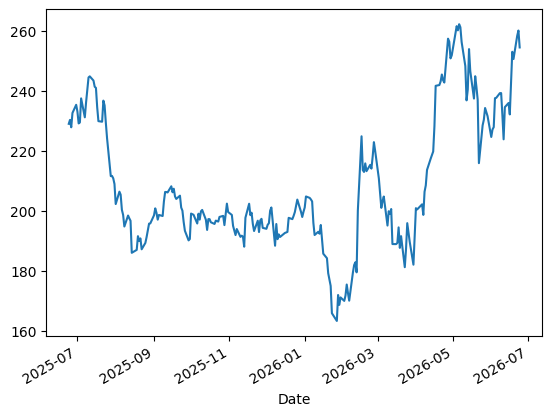

In [24]:
# feature by feature checking and outlier detection
# trend analysis
(df_equity['Close']['ENGINERSIN.NS']).isnull().sum()
(df_equity['Close']['ENGINERSIN.NS'] <0).sum() # all positive vlaues of price 
df_equity['Close']['ENGINERSIN.NS'].plot()
len(df_equity['Close']['ENGINERSIN.NS'] ) # all  rows are plotted 

# analysising return to  analyse risk 
returns  = df_equity['Close']['ENGINERSIN.NS'].pct_change()
returns.head()

np.float64(-0.00012795918272773266)

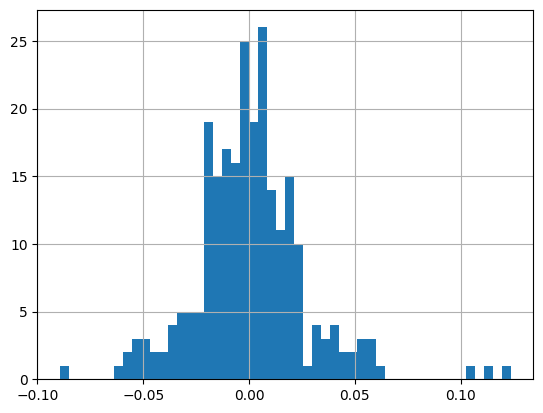

In [25]:
returns.hist(bins=50)
returns.mean() #0.000731256773761197
returns.std()#(0.026394870533377062
returns.skew()#0.7104389653985355
returns.kurt()#3.849802329994786 #moderate outliers exists 
returns.median() #(-5.287819229887747e-05)

In [26]:
re = pd.DataFrame(returns)
re.describe() #close price return 

,ENGINERSIN.NS
count,246.000000
mean,0.000775
std,0.026532
min,-0.089376
25%,-0.014712
50%,-0.000128
75%,0.012950
max,0.123717


np.float64(-0.00012795918272773266)

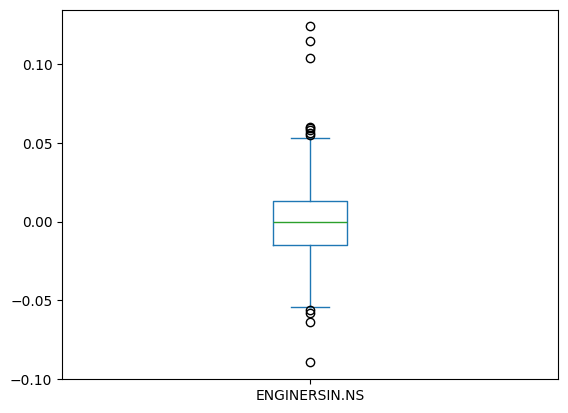

In [27]:
returns.plot.box()
q1 = returns.quantile(0.25)
q2 = returns.quantile(0.50)
q3 = returns.quantile(0.75)
q2

### Boxplot insights :
median  return is approximately nearer to 0 %
mean shows most daily returns are 0.1075 %
range of 50%( median) most of the returns lie betwwen = -0.014684854481820553 to 0.013906030606576303
in percetage = -1.46848544818205 % to +1.39060306065763
max extreme value = 12.3717 %
min extremem value = -8.94%.
outliers are visible reaseos could be

Timestamp('2026-03-13 00:00:00')

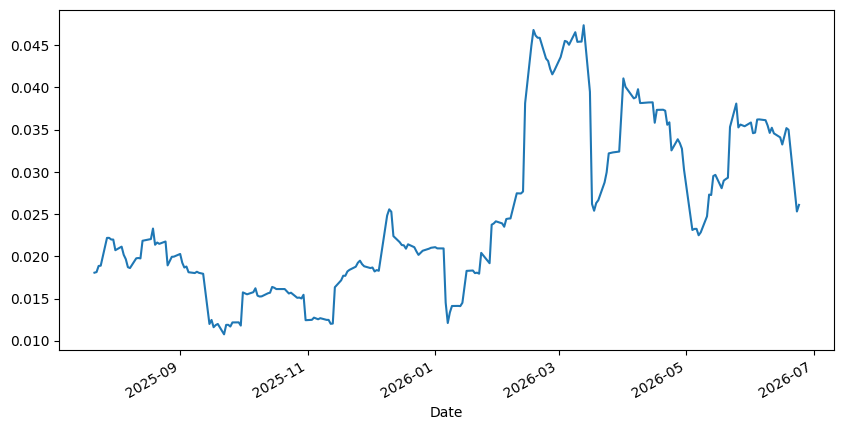

In [28]:
#rolling volati;ity 
rolling_vol = returns.rolling(window=20).std()
rolling_vol.plot(figsize=(10,5))
rolling_vol.idxmax() #'2026-03-13 00:00:00
rolling_vol.max()#(0.04736526845676808
rolling_vol.max()
rolling_vol.idxmax() #2026-03-13 00:00:00


## details of the  above chart :
the above chart shows  the returns standard deviation(volatility of 20 days window)
key observations:
2025-9(september) to 2026 - 1(january) (  predictible volality -> low risk-> low volatility)
but the risk increses  after 2026-1 it canbe aring 2nd month to 2026 -3 volatitly increses from 0.12 to 0.45 + which show unpredictable behavior -> high risk period -> high volatility 

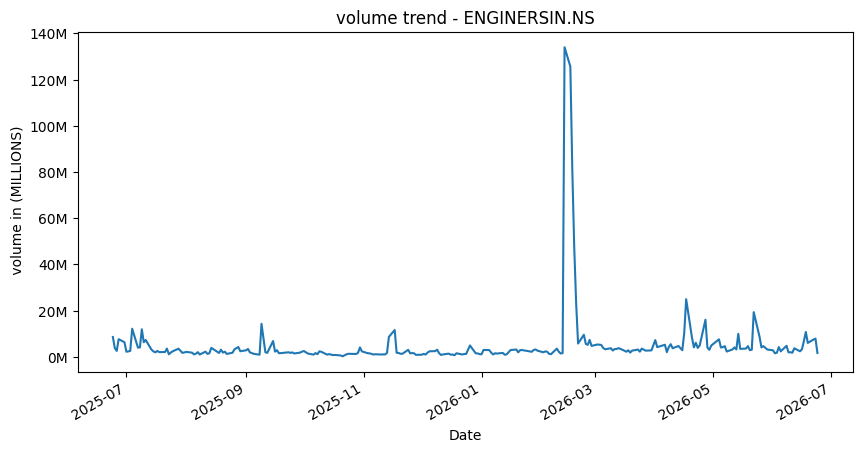

count         247.000000
mean      4893035.178138
std      13083472.657270
min        215511.000000
25%       1575391.500000
50%       2385290.000000
75%       3998421.500000
max     134019973.000000
Name: ENGINERSIN.NS, dtype: float64

In [29]:
# volume analysis
from matplotlib.ticker import FuncFormatter
volume = df_equity["Volume"]["ENGINERSIN.NS"]
volume.head()
ax = volume.plot(figsize=(10,5))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x ,pos :f"{x/1_000_000:.0f}M")
)
plt.title("volume trend - ENGINERSIN.NS")
plt.ylabel(" volume in (MILLIONS)")
plt.show()
pd.set_option('display.float_format','{:2f}'.format)
volume.describe()

In [30]:
volume.idxmax()# 2026-02-13 00:00:00
volume.max()# 134019973 


np.int64(134019973)

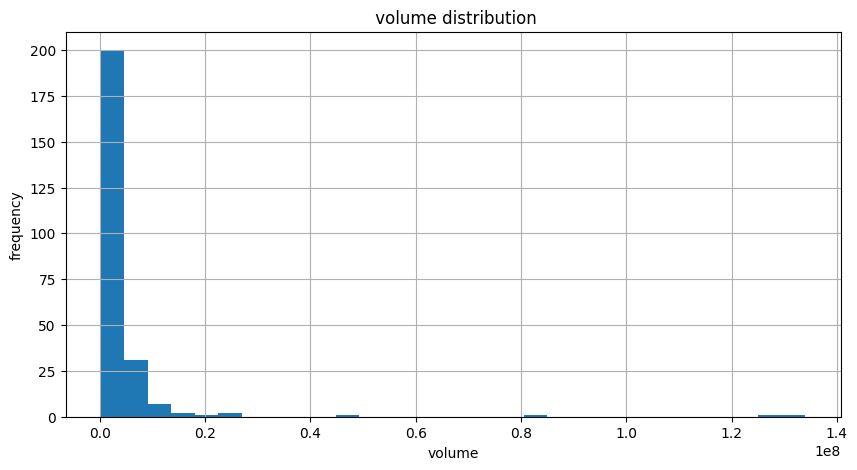

In [31]:
volume.hist(bins=30,figsize=(10,5))
plt.title(" volume distribution")
plt.xlabel("volume")
plt.ylabel("frequency")
# plt.grid(False)
plt.show()

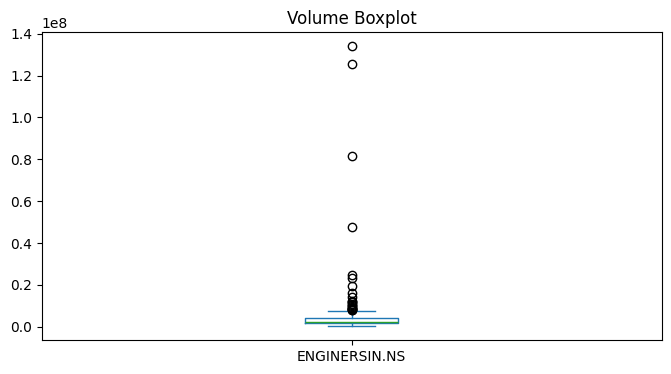

2423030.0


In [32]:
plt.figure(figsize=(8,4))
volume.plot.box()
plt.title("Volume Boxplot")
plt.show()
q1 = volume.quantile(0.25)
q3 =  volume.quantile(0.75)
iqr = q3 - q1
print(iqr)

In [34]:
df_equity.to_csv("../data/processed/cleaned_stock_data.csv")

In [36]:
df_equity.head()
df_equity.columns

MultiIndex([( 'Close', 'ENGINERSIN.NS'),
            ( 'Close',      'PARAS.NS'),
            ( 'Close',    'POLYCAB.NS'),
            (  'High', 'ENGINERSIN.NS'),
            (  'High',      'PARAS.NS'),
            (  'High',    'POLYCAB.NS'),
            (   'Low', 'ENGINERSIN.NS'),
            (   'Low',      'PARAS.NS'),
            (   'Low',    'POLYCAB.NS'),
            (  'Open', 'ENGINERSIN.NS'),
            (  'Open',      'PARAS.NS'),
            (  'Open',    'POLYCAB.NS'),
            ('Volume', 'ENGINERSIN.NS'),
            ('Volume',      'PARAS.NS'),
            ('Volume',    'POLYCAB.NS')],
           names=['Price', 'Ticker'])